# 🚀 **Neural Network Challenge: *Adult Census Income Dataset***

Build and train a Neural Network to predict whether a person earns **>50K or ≤50K** using the famous **Adult Census Income dataset**.  


## 📂 **Dataset**
- **Dataset Link (Kaggle):** 👉 [Adult Census Income Dataset](https://www.kaggle.com/datasets/wenruliu/adult-income-dataset)  
- Each row = one person’s information.  
- Features: age, education, occupation, marital status, etc.  
- Target: **income >50K (1) or ≤50K (0)** ==> **Binary Classification**. 
- **Rows:** 48842
- **Columns:** 15


| Feature           | Type        | Description                                          | Examples / Possible Values                                                                          |
|-------------------|-------------|------------------------------------------------------|-----------------------------------------------------------------------------------------------------|
| **age**           | Integer     | Age of the person                                   | 25, 32, 45                                                                                          | 
| **workclass**     | Categorical | Type of employer                                    | Private, Self-emp-not-inc, Self-emp-inc, Federal-gov, Local-gov, State-gov, Without-pay, Never-worked | 
| **fnlwgt**        | Integer     | Final sampling weight (survey-related)              | 284582, 132870                                                                                      | 
| **education**     | Categorical | Education level                                     | Bachelors, Masters, Doctorate, HS-grad, Some-college, 10th, 11th, 12th, Preschool                   | 
| **education-num** | Integer     | Numeric representation of education level           | 10, 13, 14                                                                                          | 
| **marital-status**| Categorical | Marital status                                      | Married-civ-spouse, Divorced, Never-married, Separated, Widowed                                     | 
| **occupation**    | Categorical | Occupation / Job type                               | Tech-support, Sales, Exec-managerial, Prof-specialty, Farming-fishing, Other-service, Adm-clerical  | 
| **relationship**  | Categorical | Relationship to the head of household               | Wife, Husband, Own-child, Not-in-family, Other-relative, Unmarried                                  | 
| **race**          | Categorical | Race                                                | White, Black, Asian-Pac-Islander, Amer-Indian-Eskimo, Other                                         | 
| **sex**           | Binary      | Gender                                              | Male, Female                                                                                        | 
| **capital-gain**  | Integer     | Income from capital gains / investments             | 0, 14084, 5178                                                                                      | 
| **capital-loss**  | Integer     | Loss from capital investments                       | 0, 1887, 1977                                                                                       | 
| **hours-per-week**| Integer     | Average working hours per week                      | 40, 50, 60                                                                                          | 
| **native-country**| Categorical | Country of birth                                    | United-States, Mexico, Philippines, Germany, Canada, India, Cuba, ...                               | 
| **income** (Target)| Binary     | Income (target variable to predict)                 | `>50K`, `<=50K`                                                                                     | 


## 📚 **Import Libraries**

####  Essential Python Libraries

In [489]:
import warnings
warnings.filterwarnings('ignore')

####  Data Analysis Libraries

In [490]:
import numpy as np
import pandas as pd

####  Visualization Libraries

In [491]:
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

Handling imbalanced data libraries

In [492]:
from imblearn.over_sampling import SMOTE

#### Deep Learing Libraries

Data Split Libraries

In [493]:
from sklearn.model_selection import train_test_split

Preprocessing libraries

In [494]:
# Libraries for Encoding
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from category_encoders import BinaryEncoder
# Libraries for Feature Scaling
from sklearn.preprocessing import StandardScaler, Normalizer

TensorFlow & Keras

In [495]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, BatchNormalization, Dropout, Activation


Evaluation Metrics

In [496]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_auc_score, classification_report, roc_curve, auc

---

## 📂 **Import The Data set**

In [497]:
df = pd.read_csv(r"C:\Users\lap top\Downloads\archive (10)\adult.csv")

## 🔍 **Data Exploration**

### Data Overview

In [498]:
df

,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,18,?,103497,Some-college,10,Never-married,?,Own-child,White,Female,0,0,30,United-States,<=50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48837,27,Private,257302,Assoc-acdm,12,Married-civ-spouse,Tech-support,Wife,White,Female,0,0,38,United-States,<=50K
48838,40,Private,154374,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,40,United-States,>50K
48839,58,Private,151910,HS-grad,9,Widowed,Adm-clerical,Unmarried,White,Female,0,0,40,United-States,<=50K
48840,22,Private,201490,HS-grad,9,Never-married,Adm-clerical,Own-child,White,Male,0,0,20,United-States,<=50K


In [499]:
df.shape

(48842, 15)

In [500]:
df.columns

Index(['age', 'workclass', 'fnlwgt', 'education', 'educational-num',
       'marital-status', 'occupation', 'relationship', 'race', 'gender',
       'capital-gain', 'capital-loss', 'hours-per-week', 'native-country',
       'income'],
      dtype='object')

In [501]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   age              48842 non-null  int64 
 1   workclass        48842 non-null  object
 2   fnlwgt           48842 non-null  int64 
 3   education        48842 non-null  object
 4   educational-num  48842 non-null  int64 
 5   marital-status   48842 non-null  object
 6   occupation       48842 non-null  object
 7   relationship     48842 non-null  object
 8   race             48842 non-null  object
 9   gender           48842 non-null  object
 10  capital-gain     48842 non-null  int64 
 11  capital-loss     48842 non-null  int64 
 12  hours-per-week   48842 non-null  int64 
 13  native-country   48842 non-null  object
 14  income           48842 non-null  object
dtypes: int64(6), object(9)
memory usage: 5.6+ MB


In [502]:
numerical_features = df.select_dtypes(include='int64').columns.tolist()

categorical_features = df.select_dtypes(include='object').columns.tolist()

print(f"Numerical Features: {numerical_features} | {len(numerical_features)}")
print(f"Categorical Features: {categorical_features} | {len(categorical_features)}")

Numerical Features: ['age', 'fnlwgt', 'educational-num', 'capital-gain', 'capital-loss', 'hours-per-week'] | 6
Categorical Features: ['workclass', 'education', 'marital-status', 'occupation', 'relationship', 'race', 'gender', 'native-country', 'income'] | 9


### Missing values

No missing values

In [503]:
df.isnull().sum()

age                0
workclass          0
fnlwgt             0
education          0
educational-num    0
marital-status     0
occupation         0
relationship       0
race               0
gender             0
capital-gain       0
capital-loss       0
hours-per-week     0
native-country     0
income             0
dtype: int64

### Duplicate values

In [504]:
df.duplicated().sum()

np.int64(52)

In [505]:
df.drop_duplicates(inplace=True)

In [506]:
df.duplicated().sum()

np.int64(0)

### Features Editing 

#### `?`

`?` ==> 6456 ==> 13.2%

In [507]:
for col in categorical_features:
    print(f"Value counts for {col}:\n{df[col].value_counts()}\n")

Value counts for workclass:
workclass
Private             33860
Self-emp-not-inc     3861
Local-gov            3136
?                    2795
State-gov            1981
Self-emp-inc         1694
Federal-gov          1432
Without-pay            21
Never-worked           10
Name: count, dtype: int64

Value counts for education:
education
HS-grad         15770
Some-college    10863
Bachelors        8013
Masters          2656
Assoc-voc        2060
11th             1812
Assoc-acdm       1601
10th             1389
7th-8th           954
Prof-school       834
9th               756
12th              655
Doctorate         594
5th-6th           507
1st-4th           245
Preschool          81
Name: count, dtype: int64

Value counts for marital-status:
marital-status
Married-civ-spouse       22366
Never-married            16082
Divorced                  6630
Separated                 1530
Widowed                   1518
Married-spouse-absent      627
Married-AF-spouse           37
Name: count, dtype:

In [508]:
col_replace = ['workclass', 'occupation', 'native-country']

for col in col_replace:
    df[col] = df[col].replace('?', 'Other')

In [509]:
print(df[df['workclass'] == '?'])

Empty DataFrame
Columns: [age, workclass, fnlwgt, education, educational-num, marital-status, occupation, relationship, race, gender, capital-gain, capital-loss, hours-per-week, native-country, income]
Index: []


#### `educational-num` & `education`

In [510]:
df['educational-num'].value_counts().sort_index()

educational-num
1        81
2       245
3       507
4       954
5       756
6      1389
7      1812
8       655
9     15770
10    10863
11     2060
12     1601
13     8013
14     2656
15      834
16      594
Name: count, dtype: int64

In [511]:
df[['education', 'educational-num']]

,education,educational-num
0,11th,7
1,HS-grad,9
2,Assoc-acdm,12
3,Some-college,10
4,Some-college,10
...,...,...
48837,Assoc-acdm,12
48838,HS-grad,9
48839,HS-grad,9
48840,HS-grad,9


In [512]:
df.drop(columns='education', inplace=True)

#### `marital-status`

The original `marital-status` column contains **7 categories**:
- Married-civ-spouse  
- Married-AF-spouse  
- Married-spouse-absent  
- Never-married  
- Divorced  
- Separated  
- Widowed  

Having too many categories increases the number of dummy variables after encoding, which may add unnecessary complexity.  
To simplify, we can **group similar categories together**:

1. **Married**  
   - Includes: `Married-civ-spouse`, `Married-AF-spouse`, `Married-spouse-absent`  
   - Reason: All represent some form of being married.  

2. **Not-Married**  
   - Includes: `Never-married`  
   - Reason: Person has never been married.  

3. **Separated**  
   - Includes: `Divorced`, `Separated`  
   - Reason: Both indicate some form of separation.  

4. **Widowed**  
   - Includes: `Widowed`  
   - Reason: Different situation (loss of spouse), may affect income differently.  

---

✅ Final Categories:
- `Married`  
- `Not-Married`  
- `Separated`  
- `Widowed`  

This reduces the categories from **7 → 4**, making the encoding process simpler and the model less sparse.

In [513]:
df['marital-status'] = df['marital-status'].replace({
    'Married-civ-spouse': 'Married',
    'Married-AF-spouse': 'Married',
    'Married-spouse-absent': 'Married',
    'Never-married': 'Not-Married',
    'Divorced': 'Separated',
    'Separated': 'Separated',
    'Widowed': 'Widowed'
})

#### `native-country`

In [514]:
europe = ['Germany', 'England', 'France', 'Italy', 'Poland', 'Portugal', 'Ireland', 'Scotland', 'Greece', 'Yugoslavia', 'Hungary', 'Holand-Netherlands']
asia = ['India', 'Japan', 'China', 'Philippines', 'Vietnam', 'Iran', 'Cambodia', 'Laos', 'Thailand', 'Taiwan', 'Hong', 'South']
north_america = ['Canada', 'Mexico', 'Puerto-Rico', 'Cuba', 'Dominican-Republic', 'Guatemala', 'Honduras', 'Jamaica', 'El-Salvador', 'Nicaragua', 'Trinadad&Tobago', 'Haiti']
south_america = ['Columbia', 'Ecuador', 'Peru']

def country_map(x):
    if x in europe: return 'Europe'
    elif x in asia: return 'Asia'
    elif x in north_america: return 'North America'
    elif x in south_america: return 'South America'
    elif x == 'United-States': return 'United-States'
    else: return 'Other'

df['native-country'] = df['native-country'].apply(country_map)


#### `occupation`

In [515]:
# Define mapping for occupation groups
occupation_map = {
    'Prof-specialty': 'Professional',
    'Exec-managerial': 'Professional',
    'Tech-support': 'Professional',
    
    'Craft-repair': 'Skilled-Manual',
    'Machine-op-inspct': 'Skilled-Manual',
    'Handlers-cleaners': 'Skilled-Manual',
    'Transport-moving': 'Skilled-Manual',
    
    'Adm-clerical': 'Office-Work',
    'Sales': 'Office-Work',
    
    'Other-service': 'Service',
    'Protective-serv': 'Service',
    'Priv-house-serv': 'Service',
    
    'Farming-fishing': 'Agricultural',
    
    'Armed-Forces': 'Military'
}

# Apply mapping
df['occupation'] = df['occupation'].map(occupation_map)


### Outliers

In [516]:
def outliers_detection(Dataframe, Features):

    for col in Features:
        # Calculate Q1, Q3, and IQR
        Q1 = np.quantile(Dataframe[col], 0.25)
        Q3 = np.quantile(Dataframe[col], 0.75)
        IQR = Q3 - Q1

        # Define outliers boundaries
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        # Identify outliers
        outliers = Dataframe[(Dataframe[col] < lower_bound) | (Dataframe[col] > upper_bound)]

    # Calculate number of outliers
    num_outliers = len(outliers)

    # Calculate percentage of outliers
    percentage_outliers = (len(outliers) / len(Dataframe)) * 100
    print(f"Number of outliers📉: {num_outliers}")
    print(f"Percentage of outliers 📉: {percentage_outliers:.2f}%")

In [517]:
outliers_detection(df, numerical_features)

Number of outliers📉: 13486
Percentage of outliers 📉: 27.64%


### Descriptive statistics

In [518]:
df.describe(include='int64').T

,count,mean,std,min,25%,50%,75%,max
age,48790.0,38.652798,13.708493,17.0,28.0,37.0,48.00,90.0
fnlwgt,48790.0,189668.999365,105617.231232,12285.0,117555.0,178138.5,237606.25,1490400.0
educational-num,48790.0,10.078807,2.570046,1.0,9.0,10.0,12.00,16.0
capital-gain,48790.0,1080.217688,7455.905921,0.0,0.0,0.0,0.00,99999.0
capital-loss,48790.0,87.595573,403.209129,0.0,0.0,0.0,0.00,4356.0
hours-per-week,48790.0,40.425886,12.392729,1.0,40.0,40.0,45.00,99.0


In [519]:
df.describe(include='object').T

,count,unique,top,freq
workclass,48790,9,Private,33860
marital-status,48790,4,Married,23030
occupation,45985,6,Professional,13692
relationship,48790,6,Husband,19703
race,48790,5,White,41714
gender,48790,2,Male,32614
native-country,48790,6,United-States,43792
income,48790,2,<=50K,37109


## 📈 **Pair Plot**

In [520]:
# fig_pairplot = sns.pairplot(df, hue='income')
# fig_pairplot.fig.suptitle('Pairplot of variable colored by income')
# plt.show()

## </> **Feature Engineering (Encoding)**

### Binary encoding

In [521]:
df.head()

,age,workclass,fnlwgt,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,Private,226802,7,Not-Married,Skilled-Manual,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,89814,9,Married,Agricultural,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,336951,12,Married,Service,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,160323,10,Married,Skilled-Manual,Husband,Black,Male,7688,0,40,United-States,>50K
4,18,Other,103497,10,Not-Married,NaN,Own-child,White,Female,0,0,30,United-States,<=50K


In [522]:
df['gender'] = df['gender'].map({'Male':0, 'Female':1})
df['income'] = df['income'].map({'<=50K':0, '>50K':1})

### One-Hot encoding

In [523]:
df.head()

,age,workclass,fnlwgt,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,Private,226802,7,Not-Married,Skilled-Manual,Own-child,Black,0,0,0,40,United-States,0
1,38,Private,89814,9,Married,Agricultural,Husband,White,0,0,0,50,United-States,0
2,28,Local-gov,336951,12,Married,Service,Husband,White,0,0,0,40,United-States,1
3,44,Private,160323,10,Married,Skilled-Manual,Husband,Black,0,7688,0,40,United-States,1
4,18,Other,103497,10,Not-Married,NaN,Own-child,White,1,0,0,30,United-States,0


In [524]:
onehot_enc = ['workclass', 'marital-status', 'occupation', 'relationship', 'race', 'native-country']
encoder = BinaryEncoder(cols=onehot_enc)
df_enc = encoder.fit_transform(df)

In [525]:
df_enc.head()

,age,workclass_0,workclass_1,workclass_2,workclass_3,fnlwgt,educational-num,marital-status_0,marital-status_1,marital-status_2,...,race_1,race_2,gender,capital-gain,capital-loss,hours-per-week,native-country_0,native-country_1,native-country_2,income
0,25,0,0,0,1,226802,7,0,0,1,...,0,1,0,0,0,40,0,0,1,0
1,38,0,0,0,1,89814,9,0,1,0,...,1,0,0,0,0,50,0,0,1,0
2,28,0,0,1,0,336951,12,0,1,0,...,1,0,0,0,0,40,0,0,1,1
3,44,0,0,0,1,160323,10,0,1,0,...,0,1,0,7688,0,40,0,0,1,1
4,18,0,0,1,1,103497,10,0,0,1,...,1,0,1,0,0,30,0,0,1,0


## 🧠 **Build Neural Network Model**

In [526]:
x = df_enc.drop('income', axis=1)
y = df_enc['income']

In [527]:
x_train, x_test, y_train, y_test = train_test_split(x, y, random_state=42)

In [528]:
print(F"Shape of x_train: {x_train.shape}")
print(F"Shape of y_train: {y_train.shape}")
print(F"Shape of x-test: {x_test.shape}")
print(F"Shape of y_test: {y_test.shape}")

Shape of x_train: (36592, 26)
Shape of y_train: (36592,)
Shape of x-test: (12198, 26)
Shape of y_test: (12198,)


### Feature Scaling

In [529]:
num = ['age', 'fnlwgt', 'capital-gain', 'capital-loss', 'hours-per-week']

# Initialize StandardScaler
stand_scaler = StandardScaler()

# Fit the scaler on x_train and transform both x_train and x_test
x_train[num] = stand_scaler.fit_transform(x_train[num])
x_test[num] = stand_scaler.transform(x_test[num])

### Handling Balance data
Applay Over Sampling

In [530]:
print("Before SMOTE:\n", pd.Series(y_train).value_counts())

Before SMOTE:
 income
0    27841
1     8751
Name: count, dtype: int64


In [ ]:
smote = SMOTE(sampling_strategy=0.7, random_state=42)
x_train_res, y_train_res = smote.fit_resample(x_train, y_train)

In [532]:
print("Before SMOTE:\n", pd.Series(y_train_res).value_counts())

Before SMOTE:
 income
0    27841
1    19488
Name: count, dtype: int64


### Functional Method

In [533]:
from tensorflow.keras import regularizers

In [534]:
# Creat Input Layer
input_layer = Input(shape=(26,))

# Creat Hidden Layer
# Hidden Layer 1
hl_1 = Dense(128, activation='relu', kernel_regularizer=regularizers.l2(0.01))(input_layer)
bn_1 = BatchNormalization()(hl_1)
ac_1 = Activation('relu')(bn_1)
do_1 = Dropout(0.3)(ac_1)   # Dropout 30%


# Hidden Layer 2
hl_2 = Dense(64, kernel_regularizer=regularizers.l2(0.01))(do_1)
bn_2 = BatchNormalization()(hl_2)
ac_2 = Activation('relu')(bn_2)
do_2 = Dropout(0.3)(ac_2)   # Dropout 30%


# Hidden Layer 3
hl_3 = Dense(32, activation='relu', kernel_regularizer=regularizers.l2(0.01))(do_2)
bn_3 = BatchNormalization()(hl_3)
ac_3 = Activation('relu')(bn_3)
do_3 = Dropout(0.5)(ac_3)   # Dropout 50%


# Creat Output Layer (Binary Classification)
output_layer = Dense(1, activation='sigmoid')(do_3)

# Build model
model = Model(inputs=input_layer, outputs=output_layer)

model.summary()

Model: "functional_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_8 (InputLayer)      │ (None, 26)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_28 (Dense)                │ (None, 128)            │         3,456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_21          │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_20 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_29 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_22          │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_21 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_30 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_23          │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_22 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_31 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,721 (57.50 KB)

 Trainable params: 14,273 (55.75 KB)

 Non-trainable params: 448 (1.75 KB)

Learning Rate Decay

In [535]:
# exp_schedule = tf.keras.optimizers.schedules.ExponentialDecay(
#     initial_learning_rate=0.001,      # Starting value
#     decay_steps=100,                 # Every few steps (batch) decay occurs
#     decay_rate=0.96,                # Decrease rate
#     staircase=False                 # True = Decreases suddenly (step) / False = Decreases gradually
# )

ADAM

In [536]:
# optimizer = tf.keras.optimizers.Adam(learning_rate=exp_schedule)

Compile

In [537]:
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

Early Stoping

In [538]:
early_stop = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=0.000001)

In [539]:
traing_model = model.fit(x_train_res, y_train_res, epochs=50, batch_size=265, validation_split=0.1, callbacks=[early_stop, reduce_lr])

Epoch 1/50
161/161 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.7413 - loss: 1.6635 - val_accuracy: 0.4824 - val_loss: 1.2737 - learning_rate: 0.0010
Epoch 2/50
161/161 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8041 - loss: 0.8173 - val_accuracy: 0.1861 - val_loss: 0.9705 - learning_rate: 0.0010
Epoch 3/50
161/161 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8176 - loss: 0.5449 - val_accuracy: 0.1665 - val_loss: 0.9011 - learning_rate: 0.0010
Epoch 4/50
161/161 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8203 - loss: 0.4525 - val_accuracy: 0.5221 - val_loss: 0.7787 - learning_rate: 0.0010
Epoch 5/50
161/161 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8244 - loss: 0.4192 - val_accuracy: 0.6558 - val_loss: 0.6931 - learning_rate: 0.0010
Epoch 6/50
161/161 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8269 - loss: 0.3994 - val_accuracy: 0.6865 - val_loss: 0.6437 - learning_rate: 0.0010
Epoch 7/50
161/161 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8253 - loss: 0.3960 - 

Predict

In [540]:
y_pred = model.predict(x_test)

382/382 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step


In [541]:
y_pred

array([[0.5539357 ],
       [0.5326005 ],
       [0.9039492 ],
       ...,
       [0.02254239],
       [0.60160816],
       [0.00101292]], shape=(12198, 1), dtype=float32)

In [542]:
y_pred_classes = [1 if i >= 0.5 else 0 for i in y_pred]

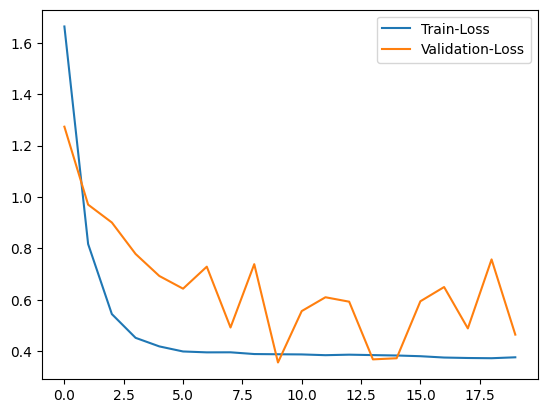

In [543]:
plt.plot(traing_model.history['loss'], label='Train-Loss')
plt.plot(traing_model.history['val_loss'], label='Validation-Loss')
plt.legend()
plt.show()

In [544]:
print("Accuracy :", accuracy_score(y_test, y_pred_classes))
print("Precision:", precision_score(y_test, y_pred_classes))
print("Recall   :", recall_score(y_test, y_pred_classes))
print("F1 Score :", f1_score(y_test, y_pred_classes))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_classes))


Accuracy : 0.8009509755697656
Precision: 0.555752998667259
Recall   : 0.8539249146757679
F1 Score : 0.6733046286329386
Confusion Matrix:
 [[7268 2000]
 [ 428 2502]]


Text(0.5, 1.0, 'Confusion Matrix')

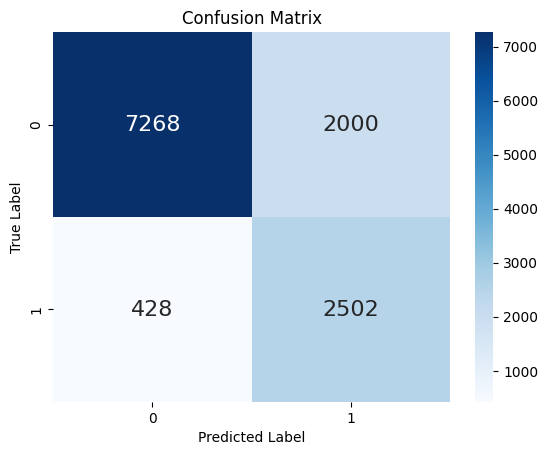

In [545]:
sns.heatmap(confusion_matrix(y_test, y_pred_classes), annot=True, fmt='d', cmap='Blues', annot_kws={"size": 16})
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')